# Mixed model: δ13C ~ Elevation (Napo)

This notebook fits a linear mixed model to test how δ13C of atmospheric CO2 varies with
elevation, using `Site` as a random intercept. It also checks whether time of day should be
included, and reports the additional statistics worth including in a supplement.

Main question: **How does δ13C vary with elevation?**


In [1]:
import pandas as pd
import numpy as np
import statsmodels.formula.api as smf
import statsmodels.api as sm
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
from scipy import stats as scistats

pd.set_option('display.width', 120)


## 1. Load and clean the data

The data live in the `Sheet1` sheet of `air_samples_Napo.xlsx`. The first data row after the
header holds the column units, so it is dropped. `Time` is parsed to decimal hours for later
use.


In [2]:
df = pd.read_excel('air_samples_Napo.xlsx', sheet_name='Sheet1', header=0)
df = df.drop(index=0).reset_index(drop=True)

df = df.rename(columns={'δ13C': 'delta13C', 'δ18O': 'delta18O', '[CO2]': 'CO2_ppm'})

for col in ['CO2_ppm', 'delta13C', 'delta18O', 'Elevacion_stm']:
    df[col] = pd.to_numeric(df[col], errors='coerce')

def to_decimal_hour(t):
    if pd.isna(t):
        return np.nan
    return t.hour + t.minute / 60 + t.second / 3600

df['Hora_decimal'] = df['Time'].apply(to_decimal_hour)

df = df.dropna(subset=['delta13C', 'Elevacion_stm', 'Site']).reset_index(drop=True)

print(f'Usable observations: {len(df)}')
print(f'Sites: {df["Site"].nunique()}')
print(f'Observations with a recorded sampling time: {df["Hora_decimal"].notna().sum()}')


Usable observations: 57
Sites: 19
Observations with a recorded sampling time: 48


### Site summary table

One row per site with elevation, number of replicates, and δ13C mean ± SD — this is the table
worth reporting alongside the model (and much easier to read than a raw list of site names).


In [3]:
site_summary = (
    df.groupby('Site', as_index=False)
      .agg(Elevation_m=('Elevacion_stm', 'first'),
           n=('delta13C', 'size'),
           delta13C_mean=('delta13C', 'mean'),
           delta13C_sd=('delta13C', 'std'))
      .sort_values('Elevation_m')
      .reset_index(drop=True)
)
site_summary['delta13C_mean'] = site_summary['delta13C_mean'].round(2)
site_summary['delta13C_sd'] = site_summary['delta13C_sd'].round(2)
site_summary


,Site,Elevation_m,n,delta13C_mean,delta13C_sd
0,Jatun Sacha,426.0,3,-10.77,0.22
1,Wisdom forest lodge,592.0,3,-11.51,0.36
2,Jondachi,972.0,3,-8.71,0.14
3,BoNu,1000.0,3,-13.63,0.21
4,Gal1000,1000.0,4,-13.46,1.67
5,Gal1500,1500.0,6,-13.41,0.79
6,Sarayacu road,1699.0,3,-9.23,0.07
7,Baeza,1917.0,3,-9.45,0.29
8,Guacamayos entrance,2256.0,3,-9.18,0.13
9,Guacamayos,2256.0,3,-9.29,0.18


## 2. Mixed model

`delta13C ~ Elevacion_stm`, with a random intercept for `Site`.


In [4]:
modelo_d13 = smf.mixedlm(
    'delta13C ~ Elevacion_stm', data=df, groups=df['Site']
).fit()
print(modelo_d13.summary())


           Mixed Linear Model Regression Results
Model:               MixedLM  Dependent Variable:  delta13C
No. Observations:    57       Method:              REML    
No. Groups:          19       Scale:               0.6474  
Min. group size:     1        Log-Likelihood:      -99.9922
Max. group size:     6        Converged:           Yes     
Mean group size:     3.0                                   
-----------------------------------------------------------
               Coef.  Std.Err.    z    P>|z|  [0.025 0.975]
-----------------------------------------------------------
Intercept     -10.968    0.963 -11.387 0.000 -12.856 -9.080
Elevacion_stm  -0.000    0.000  -0.199 0.842  -0.001  0.001
Group Var       3.169    1.731                             



## 3. Should time of day be in the model?

Atmospheric CO2's δ13C has a well-known diurnal cycle: it tends to be more depleted (more
negative) in the early morning, when respired CO2 has accumulated in a shallow, stable
boundary layer, and rises through the day as photosynthesis draws CO2 down and the boundary
layer mixes. So time of day is a real candidate driver — but in this dataset it is almost
entirely confounded with `Site`: each site was visited once, and its 1–6 replicates were
collected within the same short window (often the same hour, sometimes the same minute).

That means `Elevacion_stm`, `Site`, and `Hora_decimal` are not independent here — there isn't
enough within-site variation in sampling time to separate a "time of day" effect from a
"site/day of sampling" effect. Below is a sensitivity check: refit both the elevation-only and
the elevation+time model on the same subset (the 48 observations that have a recorded time) and
compare them.


In [5]:
df_time = df.dropna(subset=['Hora_decimal']).reset_index(drop=True)
print(f'Subset with recorded time: {len(df_time)} obs, {df_time["Site"].nunique()} sites '
      f'(drops: {sorted(set(df["Site"]) - set(df_time["Site"]))})')

modelo_sin_hora = smf.mixedlm(
    'delta13C ~ Elevacion_stm', data=df_time, groups=df_time['Site']
).fit()

modelo_con_hora = smf.mixedlm(
    'delta13C ~ Elevacion_stm + Hora_decimal', data=df_time, groups=df_time['Site']
).fit()

# AIC/BIC require an ML (not REML) fit in statsmodels' MixedLM; refit under ML just for
# these two, keeping the REML fits above for the reported coefficients/SEs.
modelo_sin_hora_ml = smf.mixedlm(
    'delta13C ~ Elevacion_stm', data=df_time, groups=df_time['Site']
).fit(reml=False)
modelo_con_hora_ml = smf.mixedlm(
    'delta13C ~ Elevacion_stm + Hora_decimal', data=df_time, groups=df_time['Site']
).fit(reml=False)

comparacion = pd.DataFrame({
    'Model': ['Elevation only (n=48 subset)', 'Elevation + time of day (n=48)'],
    'Elevation coef': [modelo_sin_hora.fe_params['Elevacion_stm'], modelo_con_hora.fe_params['Elevacion_stm']],
    'Elevation p': [modelo_sin_hora.pvalues['Elevacion_stm'], modelo_con_hora.pvalues['Elevacion_stm']],
    'Time coef': [np.nan, modelo_con_hora.fe_params['Hora_decimal']],
    'Time p': [np.nan, modelo_con_hora.pvalues['Hora_decimal']],
    'AIC (ML)': [modelo_sin_hora_ml.aic, modelo_con_hora_ml.aic],
    'BIC (ML)': [modelo_sin_hora_ml.bic, modelo_con_hora_ml.bic],
})
comparacion


Subset with recorded time: 48 obs, 16 sites (drops: ['Irquis', 'Mospa', 'Sevilla'])


,Model,Elevation coef,Elevation p,Time coef,Time p,AIC (ML),BIC (ML)
0,Elevation only (n=48 subset),-0.000124,0.764804,NaN,NaN,166.149174,173.633978
1,Elevation + time of day (n=48),-0.000127,0.768250,-0.02526,0.817712,168.148979,177.504984


**Recommendation:** given how strongly time of day is confounded with site here (one
sampling occasion per site), adding it does not give you an independently estimable "time of
day" effect — it mostly reshuffles variance that `Site` already absorbs, at the cost of 9
observations and 3 sites. Report the elevation-only model (fit on the full dataset) as the main
result, and mention the time-of-day sensitivity check above in the supplement as evidence that
your elevation conclusion is not an artifact of sampling time. If you want to test time of day
properly in the future, you'd need repeated sampling of the *same* site at different times of
day.


## 4. Additional statistics worth reporting

For a supplement, beyond the fixed-effect coefficient table it's standard to also report:
group-level variance and the intraclass correlation (how much of the total variance sits
between sites vs. within), marginal/conditional R² (variance explained by the fixed effect
alone vs. fixed+random together), AIC/BIC, and a residual diagnostic check. All computed below
for the main (elevation-only, full-data) model.


In [6]:
group_var = modelo_d13.cov_re.iloc[0, 0]
resid_var = modelo_d13.scale
icc = group_var / (group_var + resid_var)

fixed_pred = modelo_d13.fe_params['Intercept'] + modelo_d13.fe_params['Elevacion_stm'] * df['Elevacion_stm']
var_fixed = np.var(fixed_pred, ddof=0)
r2_marginal = var_fixed / (var_fixed + group_var + resid_var)
r2_conditional = (var_fixed + group_var) / (var_fixed + group_var + resid_var)

# AIC/BIC need an ML fit (statsmodels leaves them as NaN under REML)
modelo_d13_ml = smf.mixedlm(
    'delta13C ~ Elevacion_stm', data=df, groups=df['Site']
).fit(reml=False)

stats_extra = pd.DataFrame({
    'Statistic': ['N observations', 'N groups (sites)', 'Group size range',
                  'Random intercept variance (Site)', 'Residual variance', 'ICC',
                  'Marginal R2 (fixed effects only)', 'Conditional R2 (fixed + random)',
                  'AIC (ML)', 'BIC (ML)', 'Log-likelihood (REML)'],
    'Value': [modelo_d13.nobs, df['Site'].nunique(),
              f"{df.groupby('Site').size().min()}-{df.groupby('Site').size().max()}",
              round(group_var, 4), round(resid_var, 4), round(icc, 4),
              round(r2_marginal, 4), round(r2_conditional, 4),
              round(modelo_d13_ml.aic, 2), round(modelo_d13_ml.bic, 2), round(modelo_d13.llf, 2)]
})
stats_extra


,Statistic,Value
0,N observations,57
1,N groups (sites),19
2,Group size range,1-6
3,Random intercept variance (Site),3.1694
4,Residual variance,0.6474
5,ICC,0.8304
6,Marginal R2 (fixed effects only),0.0017
7,Conditional R2 (fixed + random),0.8307
8,AIC (ML),194.15
9,BIC (ML),202.32


### Residual diagnostics

Two standard checks: residuals vs. fitted values (looking for patterns/heteroscedasticity) and
a Q-Q plot (checking the normality assumption behind the p-values).


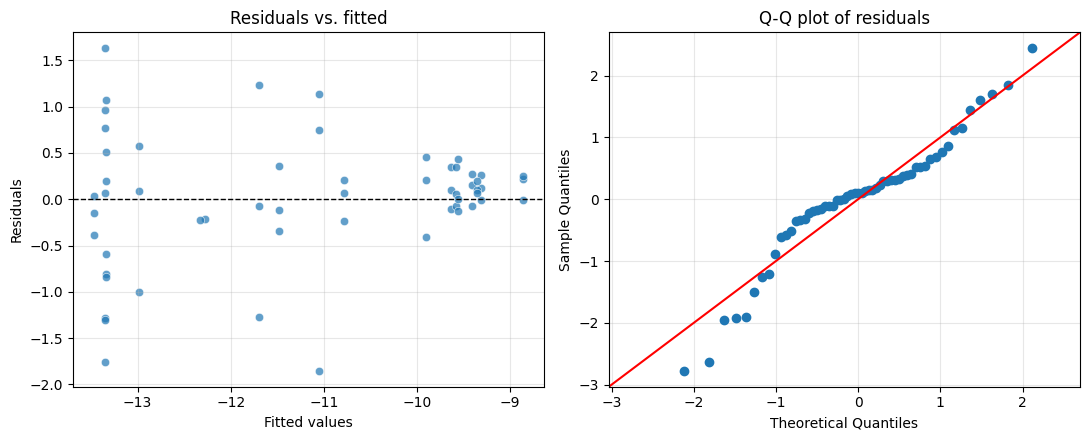

In [7]:
fitted = modelo_d13.fittedvalues
resid = modelo_d13.resid

fig, axes = plt.subplots(1, 2, figsize=(11, 4.5))

axes[0].scatter(fitted, resid, alpha=0.7, edgecolor='white', linewidth=0.5)
axes[0].axhline(0, color='black', linestyle='--', linewidth=1)
axes[0].set_xlabel('Fitted values')
axes[0].set_ylabel('Residuals')
axes[0].set_title('Residuals vs. fitted')
axes[0].grid(alpha=0.3)

sm.qqplot(resid, line='45', fit=True, ax=axes[1])
axes[1].set_title('Q-Q plot of residuals')
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.savefig('delta13C_diagnostics.png', dpi=300, bbox_inches='tight')
plt.show()


## 5. Plot: δ13C vs. elevation

Points are colored on a continuous scale by elevation (clearer than 19 discrete site colors),
with the site name labeled next to each cluster of replicates, and the fixed-effect prediction
line from the mixed model overlaid.


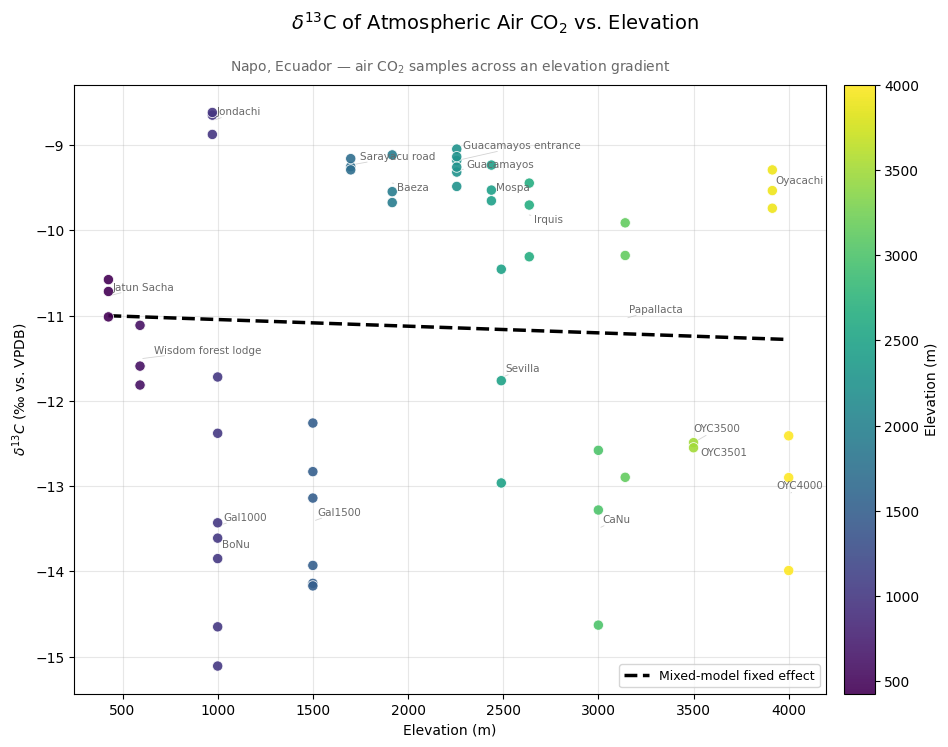

In [8]:
from adjustText import adjust_text

fig, ax = plt.subplots(figsize=(10, 7.5))

norm = plt.Normalize(df['Elevacion_stm'].min(), df['Elevacion_stm'].max())
cmap = plt.get_cmap('viridis')

sc = ax.scatter(df['Elevacion_stm'], df['delta13C'], c=df['Elevacion_stm'], cmap=cmap,
                 norm=norm, s=55, alpha=0.9, edgecolor='white', linewidth=0.6, zorder=3)

# Label each site once, near its mean position; adjustText nudges labels apart so the
# 19 site names stay legible instead of overlapping.
label_pts = df.groupby('Site', as_index=False).agg(
    x=('Elevacion_stm', 'mean'), y=('delta13C', 'mean')
)
texts = [ax.text(row['x'], row['y'], row['Site'], fontsize=7.5, color='dimgray')
         for _, row in label_pts.iterrows()]
adjust_text(texts, ax=ax,
            arrowprops=dict(arrowstyle='-', color='lightgray', lw=0.6),
            expand=(1.3, 1.6))

x_range = np.linspace(df['Elevacion_stm'].min(), df['Elevacion_stm'].max(), 100)
fe = modelo_d13.fe_params
y_pred = fe['Intercept'] + fe['Elevacion_stm'] * x_range
ax.plot(x_range, y_pred, color='black', linewidth=2.5, linestyle='--',
        label='Mixed-model fixed effect', zorder=2)

cbar = fig.colorbar(sc, ax=ax, pad=0.02)
cbar.set_label('Elevation (m)')

ax.set_xlabel('Elevation (m)')
ax.set_ylabel(r'$\delta^{13}C$ (‰ vs. VPDB)')
fig.suptitle(r'$\delta^{13}$C of Atmospheric Air CO$_2$ vs. Elevation', y=0.99, fontsize=14)
ax.set_title('Napo, Ecuador — air CO$_2$ samples across an elevation gradient',
             fontsize=10, color='dimgray', pad=10)
ax.legend(loc='lower right', fontsize=9)
ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('delta13C_vs_elevacion.png', dpi=300, bbox_inches='tight')
plt.show()


## 6. Summary table for the supplement

Coefficient, SE, p-value and 95% CI, ready to paste into supplementary material.


In [9]:
coef = modelo_d13.fe_params['Elevacion_stm']
se = modelo_d13.bse_fe['Elevacion_stm']
pval = modelo_d13.pvalues['Elevacion_stm']
ci_low, ci_high = modelo_d13.conf_int().loc['Elevacion_stm']

resumen = pd.DataFrame({
    'Parameter': ['Intercept', 'Elevacion_stm (slope)'],
    'Estimate': [modelo_d13.fe_params['Intercept'], coef],
    'SE': [modelo_d13.bse_fe['Intercept'], se],
    'p-value': [modelo_d13.pvalues['Intercept'], pval],
    '95% CI low': [modelo_d13.conf_int().loc['Intercept'][0], ci_low],
    '95% CI high': [modelo_d13.conf_int().loc['Intercept'][1], ci_high],
})
resumen


,Parameter,Estimate,SE,p-value,95% CI low,95% CI high
0,Intercept,-10.967977,0.963222,4.867885e-30,-12.855859,-9.080096
1,Elevacion_stm (slope),-0.000078,0.000392,8.421059e-01,-0.000847,0.000691


In [10]:
print(f"For every 1000 m of elevation, delta13C changes by {coef*1000:.3f} per mil "
      f"(SE={se*1000:.3f}, p={pval:.4f}, 95% CI=[{ci_low*1000:.3f}, {ci_high*1000:.3f}]).")
print(f"Random-effect (Site) variance: {group_var:.4f}")
print(f"Residual variance: {resid_var:.4f}")
print(f"ICC: {icc:.3f}  |  Marginal R2: {r2_marginal:.3f}  |  Conditional R2: {r2_conditional:.3f}")


For every 1000 m of elevation, delta13C changes by -0.078 per mil (SE=0.392, p=0.8421, 95% CI=[-0.847, 0.691]).
Random-effect (Site) variance: 3.1694
Residual variance: 0.6474
ICC: 0.830  |  Marginal R2: 0.002  |  Conditional R2: 0.831
